In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import glob

def generate_synthetic_images_with_steps(
    csv_file,
    image_height=800,
    image_width=800,
    cell_size=30,
    steps=5,
    save_dir="synthetic_images"
):
    """
    Generates synthetic images with gradually increasing cell count.

    Parameters:
    -----------
    csv_file : str
        Path to a CSV file containing real cell coordinates.
    image_height, image_width : int
        Dimensions of the synthetic image.
    cell_size : int
        Approximate size of each cell (ellipse).
    steps : int
        Number of incremental steps to generate images.
    save_dir : str
        Directory where synthetic images will be saved.

    Returns:
    --------
    None (Saves images automatically)
    """

    os.makedirs(save_dir, exist_ok=True)

    file_name = os.path.splitext(os.path.basename(csv_file))[0]

    df = pd.read_csv(csv_file)
    if not {"X", "Y"}.issubset(df.columns):
        raise ValueError(f"CSV file {csv_file} must contain 'X' and 'Y' columns")

    max_x, max_y = df["X"].max(), df["Y"].max()
    if max_x > image_width or max_y > image_height:
        df["X"] = (df["X"] / max_x) * image_width
        df["Y"] = (df["Y"] / max_y) * image_height

    cell_positions = df[["X", "Y"]].astype(int).values
    total_cells = len(cell_positions)

    step_sizes = np.linspace(1, total_cells, steps, dtype=int)

    for step_idx, num_cells in enumerate(step_sizes, start=1):
        selected_positions = cell_positions[:num_cells]

        background_intensity = np.random.uniform(10, 30)
        synthetic_image = np.random.normal(background_intensity, 5, (image_height, image_width)).astype(np.float32)

        def place_cell(base_image, center_x, center_y, cell_size):
            axis_lengths = (
                np.random.randint(int(cell_size * 0.4), int(cell_size * 0.6)),
                np.random.randint(int(cell_size * 0.4), int(cell_size * 0.6))
            )
            angle = np.random.uniform(0, 360)
            cv2.ellipse(
                base_image,
                (center_x, center_y),
                axis_lengths,
                angle,
                0,
                360,
                255,
                thickness=-1
            )

        for center_x, center_y in selected_positions:
            place_cell(synthetic_image, center_x, center_y, cell_size)

        alpha = np.random.uniform(0.8, 1.2)
        beta = np.random.uniform(-20, 20)
        synthetic_image = alpha * synthetic_image + beta
        synthetic_image = np.clip(synthetic_image, 0, 255).astype(np.uint8)

        synthetic_image_path = os.path.join(save_dir, f"synthetic_image_{file_name}_step{step_idx}.png")
        cv2.imwrite(synthetic_image_path, synthetic_image)
        print(f"Step {step_idx}/{steps}: Saved {synthetic_image_path}")

    print(f"\n{steps} synthetic images generated for {file_name}!")


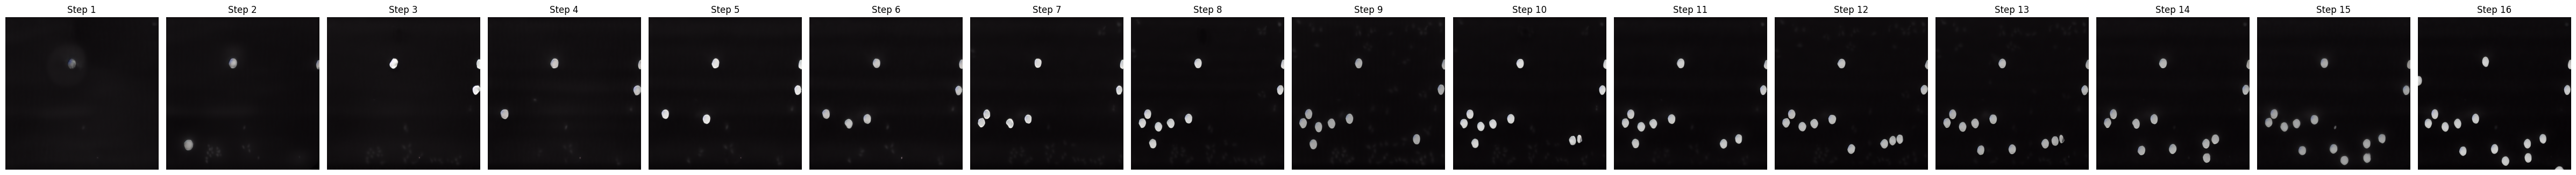

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import glob

# Path with wildcard to match all step1 to step16 images
path_pattern = '/img2img-samples/synthetic_image_220909_GFP-AHPC_A_GFAP_F4_Cy3_ND2_20x_step*-*-*.png'

# Find and sort files by step number
image_files = sorted(glob.glob(path_pattern), key=lambda x: int(x.split('_step')[1].split('-')[0]))

# Set figure size based on number of images
plt.figure(figsize=(len(image_files)*3, 5))

# Plot each image
for idx, file in enumerate(image_files):
    img = Image.open(file)
    plt.subplot(1, len(image_files), idx+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Step {idx+1}")

plt.tight_layout()
plt.savefig('output_steps_plot.png', dpi=300, bbox_inches='tight')
plt.show()

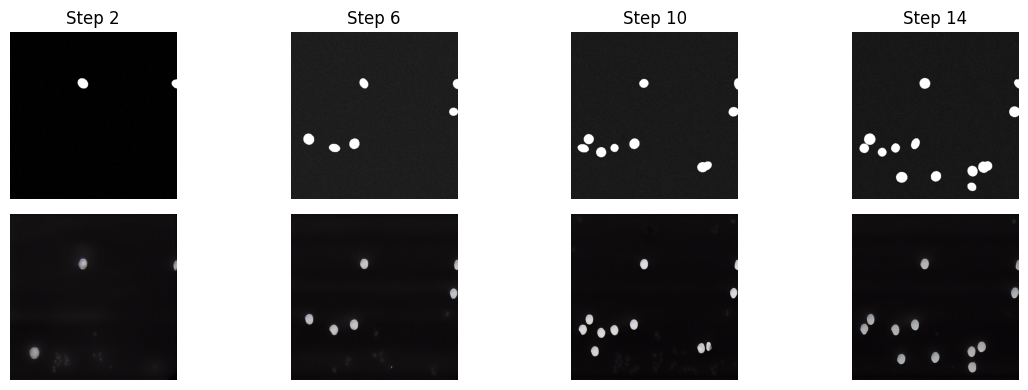

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Define the steps you want to show
steps = [2, 6, 10, 14]

# Base paths
syn_base = 'syn_images_from_csv_cs_10_grad'
out_base = 'outputs_2/img2img-samples'

# Prepare figure
fig, axes = plt.subplots(2, len(steps), figsize=(len(steps)*3, 4))

for i, step in enumerate(steps):
    # Build filenames
    syn_path = f"{syn_base}/synthetic_image_220909_GFP-AHPC_A_GFAP_F4_Cy3_ND2_20x_step{step}.png"
    out_pattern = f"{out_base}/synthetic_image_220909_GFP-AHPC_A_GFAP_F4_Cy3_ND2_20x_step{step}-*-*.png"

    # Load synthetic image
    syn_img = Image.open(syn_path)
    axes[0, i].imshow(syn_img, cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Step {step}")

    # Load diffusion image (assuming only one match per pattern)
    import glob
    out_matches = glob.glob(out_pattern)
    if out_matches:
        out_img = Image.open(out_matches[0])
        axes[1, i].imshow(out_img)
    else:
        axes[1, i].text(0.5, 0.5, 'Not found', ha='center', va='center')
    axes[1, i].axis('off')

# Add row labels
axes[0, 0].set_ylabel('Synthetic', fontsize=12)
axes[1, 0].set_ylabel('Output', fontsize=12)

plt.tight_layout()
plt.savefig('steps_2_6_10_14_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
import argparse, os, sys, glob
import PIL
import torch
import torch.nn as nn
import numpy as np
from omegaconf import OmegaConf
from PIL import Image
from tqdm import tqdm, trange
from itertools import islice
from einops import rearrange, repeat
from torchvision.utils import make_grid
from torch import autocast
from contextlib import nullcontext
import time
from pytorch_lightning import seed_everything

sys.path.append(os.path.dirname(sys.path[0]))
from ldm.util import instantiate_from_config
from ldm.models.diffusion.ddim import DDIMSampler
from ldm.models.diffusion.plms import PLMSSampler

from transformers import CLIPProcessor, CLIPModel

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

def chunk(it, size):
    it = iter(it)
    return iter(lambda: tuple(islice(it, size)), ())


def load_model_from_config(config, ckpt, verbose=False):
    print(f"Loading model from {ckpt}")
    pl_sd = torch.load(ckpt, map_location="cpu")
    if "global_step" in pl_sd:
        print(f"Global Step: {pl_sd['global_step']}")
    sd = pl_sd["state_dict"]
    model = instantiate_from_config(config.model)
    m, u = model.load_state_dict(sd, strict=False)
    if len(m) > 0 and verbose:
        print("missing keys:")
        print(m)
    if len(u) > 0 and verbose:
        print("unexpected keys:")
        print(u)

    model.to(device)
    model.eval()
    return model


def load_img(path):
    image = Image.open(path).convert("RGB")
    w, h = image.size
    print(f"loaded input image of size ({w}, {h}) from {path}")
    w, h = map(lambda x: x - x % 32, (w, h))  # resize to integer multiple of 32
    image = image.resize((512, 512), resample=PIL.Image.LANCZOS)
    image = np.array(image).astype(np.float32) / 255.0
    image = image[None].transpose(0, 3, 1, 2)
    image = torch.from_numpy(image)
    return 2.*image - 1.

def adain(content_feat, style_feat):
    assert (content_feat.size()[:2] == style_feat.size()[:2])
    size = content_feat.size()
    style_mean, style_std = calc_mean_std(style_feat)
    content_mean, content_std = calc_mean_std(content_feat)

    normalized_feat = (content_feat - content_mean.expand(
        size)) / content_std.expand(size)
    return normalized_feat * style_std.expand(size) + style_mean.expand(size)


def calc_mean_std(feat, eps=1e-5):
    # eps is a small value added to the variance to avoid divide-by-zero.
    size = feat.size()
    assert (len(size) == 4)
    N, C = size[:2]
    feat_var = feat.view(N, C, -1).var(dim=2) + eps
    feat_std = feat_var.sqrt().view(N, C, 1, 1)
    feat_mean = feat.view(N, C, -1).mean(dim=2).view(N, C, 1, 1)
    return feat_mean, feat_std

/work/LAS/tavanapo-lab/Mdehghan/venvs/torch25/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def main(prompt = '', content_dir = '', style_dir='',ddim_steps = 50,strength = 0.5, model = None, seed=42, outdir="outputs_DAPI_512_one_epoch/img2img-samples"):
    ddim_eta=0.0
    n_iter=1
    C=4
    f=8
    n_samples=1
    n_rows=0
    scale=10.0

    precision="autocast"
    # outdir="outputs_DAPI_512_one_epoch/img2img-samples"
    seed_everything(seed)


    os.makedirs(outdir, exist_ok=True)
    outpath = outdir

    batch_size = n_samples
    n_rows = n_rows if n_rows > 0 else batch_size
    data = [batch_size * [prompt]]


    sample_path = os.path.join(outpath, "samples")
    os.makedirs(sample_path, exist_ok=True)
    base_count = len(os.listdir(sample_path))
    grid_count = len(os.listdir(outpath)) + 10

    style_image = load_img(style_dir).to(device)
    style_image = repeat(style_image, '1 ... -> b ...', b=batch_size)
    style_latent = model.get_first_stage_encoding(model.encode_first_stage(style_image))  # move to latent space

    content_name =  content_dir.split('/')[-1].split('.')[0]
    content_image = load_img(content_dir).to(device)
    content_image = repeat(content_image, '1 ... -> b ...', b=batch_size)
    content_latent = model.get_first_stage_encoding(model.encode_first_stage(content_image))  # move to latent space

    init_latent = adain(content_latent,style_latent) # with AdaIN
    # init_latent = content_latent # without AdaIN

    sampler.make_schedule(ddim_num_steps=ddim_steps, ddim_eta=ddim_eta, verbose=False)

    assert 0. <= strength <= 1., 'can only work with strength in [0.0, 1.0]'
    t_enc = int(strength * ddim_steps)
    print(f"target t_enc is {t_enc} steps")

    precision_scope = autocast if precision == "autocast" else nullcontext
    with torch.no_grad():
        with precision_scope("cuda"):
            with model.ema_scope():
                tic = time.time()
                all_samples = list()
                for n in trange(n_iter, desc="Sampling"):
                    for prompts in tqdm(data, desc="data"):
                        uc = None
                        if scale != 1.0:
                            uc = model.get_learned_conditioning(batch_size * [""], style_image)
                        if isinstance(prompts, tuple):
                            prompts = list(prompts)

                        c= model.get_learned_conditioning(prompts, style_image)

                        # img2img

                        # stochastic encode
                        # z_enc = sampler.stochastic_encode(init_latent, torch.tensor([t_enc]*batch_size).to(device))

                        # stochastic inversion
                        t_enc = int(strength * 1000)
                        x_noisy = model.q_sample(x_start=init_latent, t=torch.tensor([t_enc]*batch_size).to(device))
                        model_output = model.apply_model(x_noisy, torch.tensor([t_enc]*batch_size).to(device), c)
                        z_enc = sampler.stochastic_encode(init_latent, torch.tensor([t_enc]*batch_size).to(device),\
                                                          noise = model_output, use_original_steps = True)

                        t_enc = int(strength * ddim_steps)
                        samples = sampler.decode(z_enc, c, t_enc,
                                                unconditional_guidance_scale=scale,
                                                 unconditional_conditioning=uc,)
                        print(z_enc.shape, uc.shape, t_enc)

                        # txt2img
            #             noise  =torch.randn_like(content_latent)
            #             samples, intermediates =sampler.sample(ddim_steps,1,(4,512,512),c,verbose=False, eta=1.,x_T = noise,
            #    unconditional_guidance_scale=scale,
            #    unconditional_conditioning=uc,)

                        x_samples = model.decode_first_stage(samples)

                        x_samples = torch.clamp((x_samples + 1.0) / 2.0, min=0.0, max=1.0)

                        for x_sample in x_samples:
                            x_sample = 255. * rearrange(x_sample.cpu().numpy(), 'c h w -> h w c')
                            base_count += 1
                        all_samples.append(x_samples)

                # additionally, save as grid
                grid = torch.stack(all_samples, 0)
                grid = rearrange(grid, 'n b c h w -> (n b) c h w')
                grid = make_grid(grid, nrow=n_rows)

                # to image
                grid = 255. * rearrange(grid, 'c h w -> h w c').cpu().numpy()
                output = Image.fromarray(grid.astype(np.uint8))
                output.save(os.path.join(outpath, content_name+'-'+prompt+f'-{grid_count:04}.png'))
                # Image.fromarray(grid.astype(np.uint8)).save(os.path.join(outpath, f'grid-{grid_count:04}.png'))
                grid_count += 1

                toc = time.time()
    return output

In [7]:
config="configs/stable-diffusion/v1-inference.yaml"
ckpt="models/sd/sd-v1-4.ckpt"
config = OmegaConf.load(f"{config}")
model = load_model_from_config(config, f"{ckpt}")
sampler = DDIMSampler(model)

Loading model from models/sd/sd-v1-4.ckpt


/scratch/mdehghan/6082676/ipykernel_1870656/639366397.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pl_sd = torch.load(ckpt, map_location="cpu")


Global Step: 470000
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 859.52 M params.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels


Downloading: "https://github.com/DagnyT/hardnet/raw/master/pretrained/train_liberty_with_aug/checkpoint_liberty_with_aug.pth" to /scratch/mdehghan/6082676/.cache/torch/hub/checkpoints/checkpoint_liberty_with_aug.pth
100%|██████████| 5.10M/5.10M [00:00<00:00, 43.3MB/s]


In [ ]:
# model.embedding_manager.load('/checkpoints/embeddings.pt')
model.embedding_manager.load('/checkpoints/embeddings_gs-1000.pt')

model = model.to(device)

find keys: dict_keys(['string_to_token', 'attention'])


/work/LAS/tavanapo-lab/Mdehghan/clones/InST/ldm/modules/embedding_manager.py:132: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cp

In [ ]:
# # a good image with lots of cells "220812_GFP-AHPC_B_MAP2ab_F1_DAPI_ND1_20x"
# for i in range(1,50, 3):
#      main(prompt = '*', \
#           content_dir = f'/syn_images_from_csv_cs_10_grad/synthetic_image_220909_GFP-AHPC_B_GFAP_F4_DAPI_ND1_20x_step{i}.png', \
#           style_dir = '/220909_GFP-AHPC_B_GFAP_F4_DAPI_ND1_20x.tiff', \
#           ddim_steps = 50, \
#           strength = 0.7, \
#           seed=42, \
#           model = model)

In [ ]:
# import os

# # Define directories
# synthetic_dir = "/syn_images_from_csv_cs_15"
# style_dir = "/datasets/IDCAI_v1/images/DAPI"

# # Loop through synthetic images
# for filename in os.listdir(synthetic_dir):
#     if filename.startswith("synthetic_image_") and filename.endswith(".png"):  # Filter relevant files
#         base_name = filename.replace("synthetic_image_", "").replace(".png", ".tiff")  # Remove prefix and change extension

#         # Construct the corresponding style image path
#         style_image_path = os.path.join(style_dir, base_name)

#         # Ensure the corresponding style image exists
#         if os.path.exists(style_image_path):
#             for i in range(1, 5):  # Run for steps 1 to 4
#                 main(
#                     prompt='*',
#                     content_dir=os.path.join(synthetic_dir, filename),  # Use original filename for content
#                     style_dir=style_image_path,  # Use corrected base name for style image
#                     ddim_steps=50,
#                     strength=0.7,
#                     seed=42,
#                     model=model
#                 )

# print("Processing completed for all synthetic images.")

In [ ]:
import os
import glob
import re

# Define paths
content_dir = "/datasets/IDCAI_v1/DAPI_syn_hard_coded_512_15_max_15"
style_dir = "/datasets/IDCAI_v1/images/DAPI"

# Get all synthetic content images
content_images = sorted(glob.glob(os.path.join(content_dir, "*.png")))

# Loop through all content images and find corresponding style images
for content_image in content_images:
    # Extract base filename from synthetic image
    filename = os.path.basename(content_image)  # e.g., "synthetic_image_220909_GFP-AHPC_A_GFAP_F4_DAPI_ND1_20x_0_256.png"
    
    # Remove "synthetic_image_" prefix
    # style_filename = filename.replace("synthetic_image_", "")
    # Remove the prefix and trailing "_number_number"
    style_filename = re.sub(r"synthetic_image_|_\d+_\d+(?=\..*$)", "", filename)

    # Change the extension to .tiff
    style_filename = style_filename.replace(".png", ".tiff")
    
    # Construct the full path for the style image
    style_image = os.path.join(style_dir, style_filename)
    
    # Check if the style image exists before running main()
    if os.path.exists(style_image):
        print(f"Processing:\n  Content: {content_image}\n  Style: {style_image}")
        
        main(
            prompt="*",
            content_dir=content_image,
            style_dir=style_image,
            ddim_steps=50,
            strength=0.7,
            seed=42,
            model=model,
            outdir="outputs_DAPI_512_cs_15_max_15_all/img2img-samples"
        )
    else:
        print(f"Skipping {content_image}: No matching style image found.")

Global seed set to 42


Processing:
  Content: /work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/DAPI_syn_hard_coded_512_15_max_15/synthetic_image_220909_GFP-AHPC_A_GFAP_F10_DAPI_ND1_20x_0_0.png
  Style: /work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/images/DAPI/220909_GFP-AHPC_A_GFAP_F10_DAPI_ND1_20x.tiff
loaded input image of size (800, 600) from /work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/images/DAPI/220909_GFP-AHPC_A_GFAP_F10_DAPI_ND1_20x.tiff
loaded input image of size (512, 512) from /work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/DAPI_syn_hard_coded_512_15_max_15/synthetic_image_220909_GFP-AHPC_A_GFAP_F10_DAPI_ND1_20x_0_0.png
target t_enc is 35 steps


Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

Running DDIM Sampling with 35 timesteps




















Sampling: 100%|██████████| 1/1 [00:02<00:00,  2.49s/it]


...

Processing:
  Content: /work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/DAPI_syn_hard_coded_512_15_max_15/synthetic_image_220912_GFP-AHPC_C_TuJ1_F9_DAPI_ND1_20x_256_512.png
  Style: /work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/images/DAPI/220912_GFP-AHPC_C_TuJ1_F9_DAPI_ND1_20x.tiff
loaded input image of size (800, 600) from /work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/images/DAPI/220912_GFP-AHPC_C_TuJ1_F9_DAPI_ND1_20x.tiff
loaded input image of size (512, 512) from /work/LAS/tavanapo-lab/Mdehghan/datasets/IDCAI_v1/DAPI_syn_hard_coded_512_15_max_15/synthetic_image_220912_GFP-AHPC_C_TuJ1_F9_DAPI_ND1_20x_256_512.png
target t_enc is 35 steps


Sampling:   0%|          | 0/1 [00:00<?, ?it/s]

Running DDIM Sampling with 35 timesteps




















Sampling: 100%|██████████| 1/1 [00:02<00:00,  2.20s/it]


torch.Size([1, 4, 64, 64]) torch.Size([1, 77, 768]) 35
